In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

base_path = '/content/drive/MyDrive/Datasets/CIC-IDS2018'
file_names = ['02-14-2018.csv', '02-15-2018.csv', '02-16-2018.csv', '02-20-2018.csv',
              '02-21-2018.csv', '02-22-2018.csv', '02-23-2018.csv', '02-28-2018.csv',
              '03-01-2018.csv', '03-02-2018.csv']

all_chunks = []

for name in file_names:
    full_path = os.path.join(base_path, name)
    if os.path.exists(full_path):
        print(f"Обработка на: {name}...")

        # За големия файл използваме четене на части (chunking)
        # 100,000 реда наведнъж е безопасно за RAM паметта
        try:
            reader = pd.read_csv(full_path, chunksize=100000, low_memory=False)

            for chunk in reader:
                chunk.columns = chunk.columns.str.strip()
                # Вземаме много малка извадка от всяка част (напр. 1% или 2%)
                # Дори 1% от 4GB е огромно количество данни за обучение
                sample_chunk = chunk.sample(frac=0.01, random_state=42)
                all_chunks.append(sample_chunk)

            print(f"Завършен: {name}")
        except Exception as e:
            print(f"Грешка при четене на файла {name}: {e}")
    else:
        print(f"Файлът не е намерен: {name}. Пропускане...")

# Обединяваме всичко накрая
if all_chunks:
    df = pd.concat(all_chunks, axis=0, ignore_index=True)
    print(f"Общо редове след оптимизираното четене: {len(df)}")
else:
    print("Няма заредени данни. Списъкът с части е празен.")

Обработка на: 02-14-2018.csv...
Завършен: 02-14-2018.csv
Обработка на: 02-15-2018.csv...
Завършен: 02-15-2018.csv
Обработка на: 02-16-2018.csv...
Завършен: 02-16-2018.csv
Обработка на: 02-20-2018.csv...
Завършен: 02-20-2018.csv
Обработка на: 02-21-2018.csv...
Завършен: 02-21-2018.csv
Обработка на: 02-22-2018.csv...
Завършен: 02-22-2018.csv
Обработка на: 02-23-2018.csv...
Завършен: 02-23-2018.csv
Обработка на: 02-28-2018.csv...
Завършен: 02-28-2018.csv
Обработка на: 03-01-2018.csv...
Завършен: 03-01-2018.csv
Обработка на: 03-02-2018.csv...
Завършен: 03-02-2018.csv
Общо редове след оптимизираното четене: 162331


In [ ]:
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC # Използваме LinearSVC, защото стандартният SVM е твърде бавен за тези данни

# 1. Зареждане на данни (пример с един файл, можеш да ги обединиш с pd.concat)
# Замени 'filename.csv' с името на твоя качен файл
# df = pd.read_csv('Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')

# Почистване на колоните (премахване на интервали)
df.columns = df.columns.str.strip()

# Премахване на NaN и Infinity стойности
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Избор на извадка за скорост (напр. 50,000 реда)
# df = df.sample(n=50000, random_state=42)

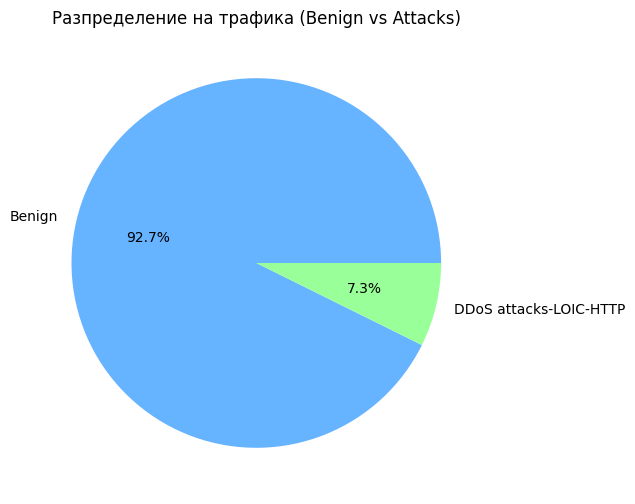

In [ ]:
plt.figure(figsize=(8,6))
df['Label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Разпределение на трафика (Benign vs Attacks)')
plt.ylabel('')
plt.show()

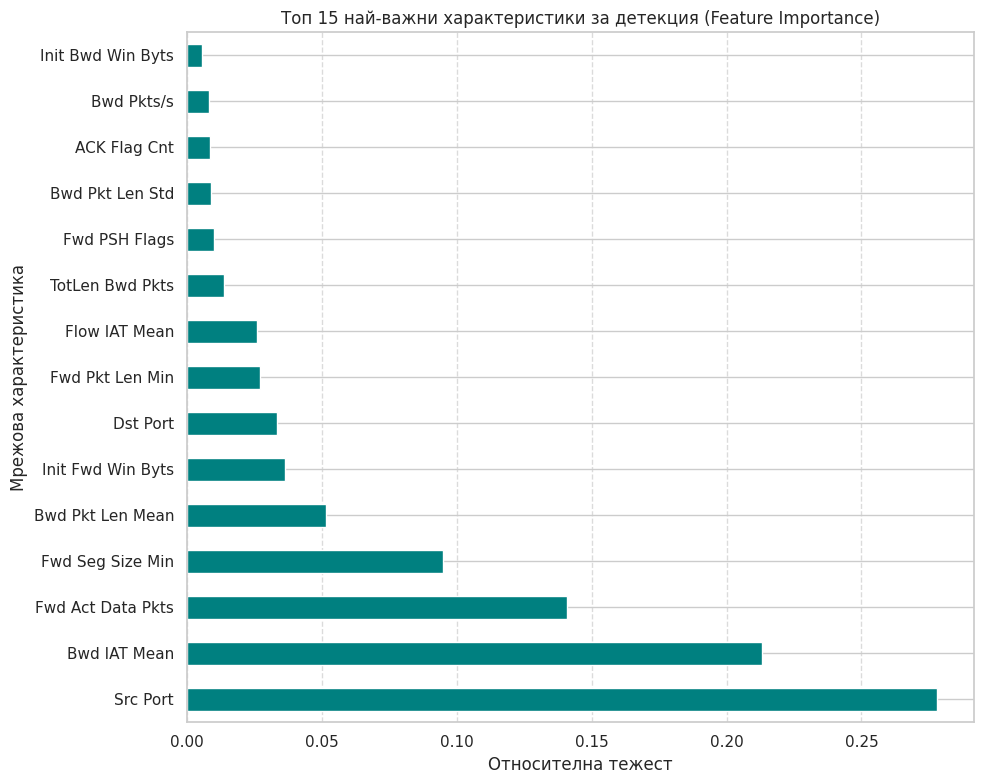

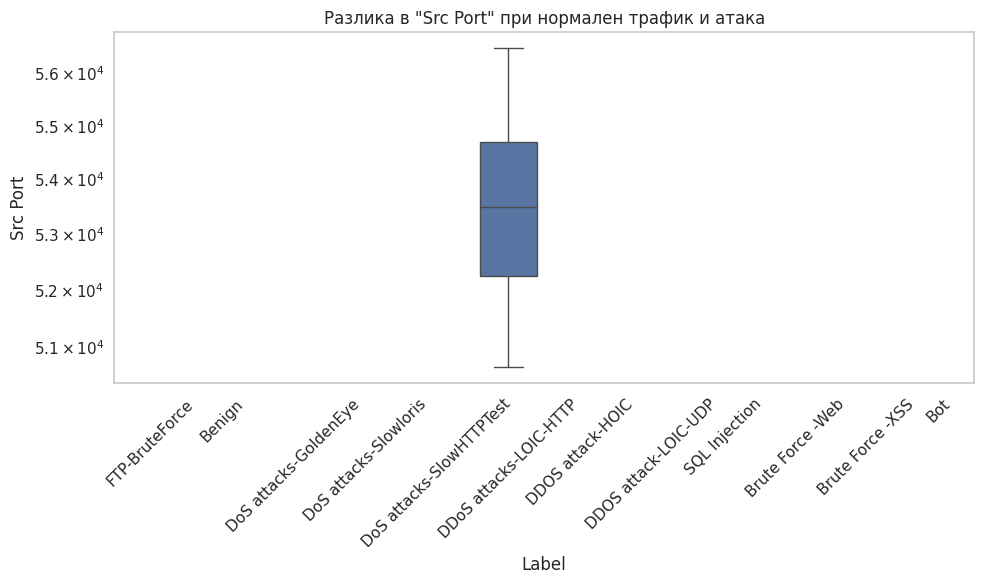

Най-важната характеристика за твоя модел е: Src Port


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd # Ensure pandas is imported if not already
import numpy as np

# 1. Подготовка на данните - премахваме ненужни колони и изчистваме
# Обикновено Timestamp и ID не помагат на модела
cols_to_drop = ['Timestamp', 'Flow ID', 'Src IP', 'Dst IP'] # Добавени са 'Flow ID', 'Src IP', 'Dst IP'

initial_df_rows = df.shape[0] # Записваме броя на редовете преди почистване

# Конвертираме всички "object" колони в числов тип, принуждавайки грешките да станат NaN
# Избягваме колоната 'Label', тъй като тя е целева променлива и ще бъде енкодирана по-късно
for col in df.columns:
    if df[col].dtype == 'object' and col not in cols_to_drop and col != 'Label':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Изрично заместваме inf стойностите с NaN, преди да запълним NaN с 0
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Вместо да премахваме редове с NaN, ще ги запълним с 0, за да избегнем изпразване на DataFrame
df.fillna(0, inplace=True)

current_df_rows = df.shape[0]
if current_df_rows < initial_df_rows:
    print(f"При обработката бяха коригирани {initial_df_rows - current_df_rows} реда с липсващи или нечислови стойности чрез запълване с 0.")

# Сега дефинираме X и y от почистения DataFrame
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns] + ['Label'])
y = df['Label']

# Енкодинг на Label (XGBoost изисква числа)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Обучение на XGBoost за анализ
# Използваме малко дървета за бързина, но достатъчно за анализ
model_analysis = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
model_analysis.fit(X, y_encoded)

# --- ГРАФИКА 1: Feature Importance ---
plt.figure(figsize=(10, 8))
# Вземаме топ 15 характеристики
feat_importances = pd.Series(model_analysis.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh', color='teal')
plt.title('Топ 15 най-важни характеристики за детекция (Feature Importance)')
plt.xlabel('Относителна тежест')
plt.ylabel('Мрежова характеристика')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feature_importance.png') # Запази за Word документа
plt.show()

# --- ГРАФИКА 2: Анализ на аномалиите (Визуализация на топ характеристика) ---
# Намираме най-важната характеристика автоматично
top_feature = feat_importances.idxmax()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Label', y=top_feature, data=df)
plt.yscale('log') # Използваме логаритмична скала, тъй като стойностите често варират много
plt.title(f'Разлика в "{top_feature}" при нормален трафик и атака')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('anomaly_analysis.png') # Запази за Word документа
plt.show()

print(f"Най-важната характеристика за твоя модел е: {top_feature}")

/tmp/ipykernel_58693/4068000284.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_features.values, y=top_15_features.index, palette="viridis")


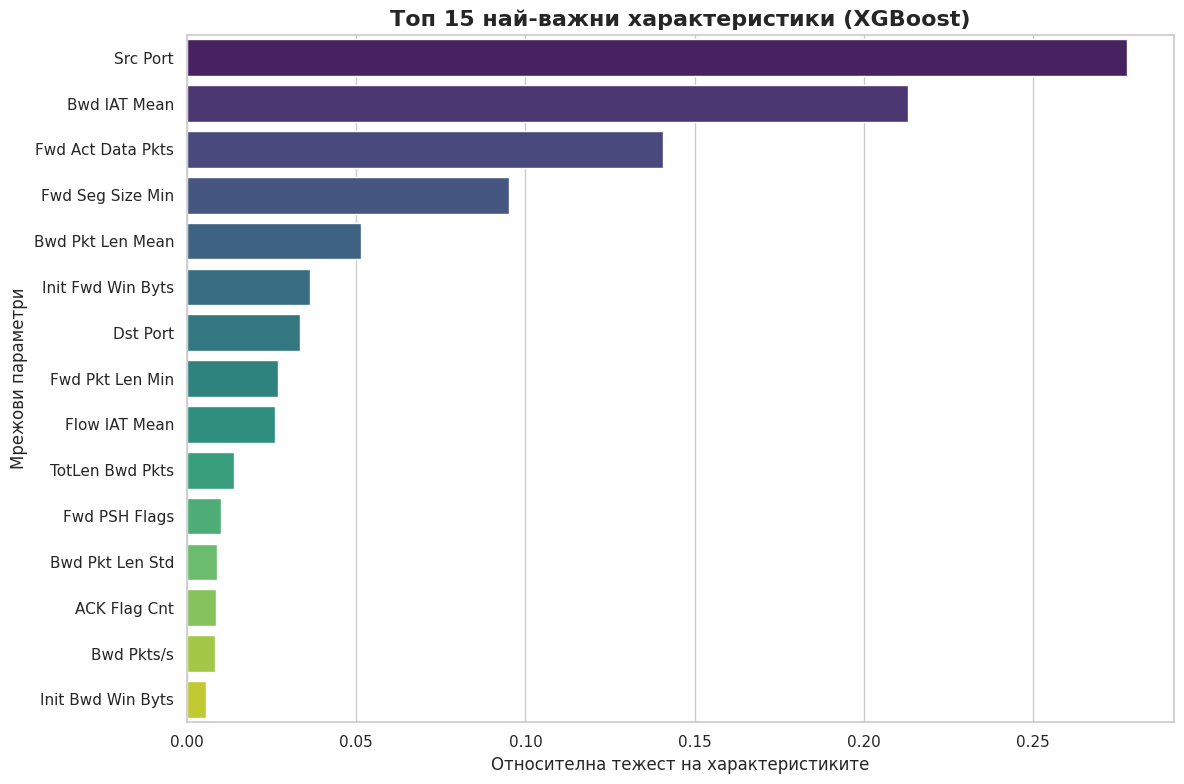

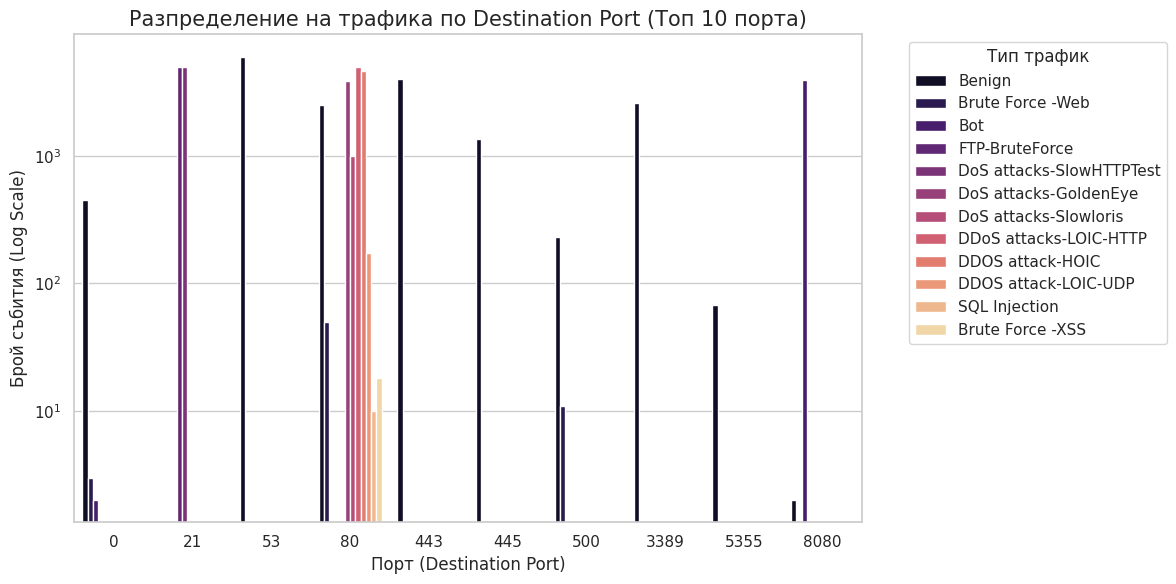

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Задаваме професионален стил на графиките
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# --- ГРАФИКА 1: Feature Importance (Коригирана) ---
plt.figure(figsize=(12, 8))
feat_importances = pd.Series(model_analysis.feature_importances_, index=X.columns)
top_15_features = feat_importances.nlargest(15)

# Използваме Seaborn за по-красива и сигурна визуализация
sns.barplot(x=top_15_features.values, y=top_15_features.index, palette="viridis")

plt.title('Топ 15 най-важни характеристики (XGBoost)', fontsize=16, fontweight='bold')
plt.xlabel('Относителна тежест на характеристиките', fontsize=12)
plt.ylabel('Мрежови параметри', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_final.png')
plt.show()

# --- ГРАФИКА 2: Анализ на Destination Port (Dst Port) ---
# Тъй като Dst Port е дискретна стойност, Violin plot или Stripplot е по-подходящ
plt.figure(figsize=(12, 6))

# Показваме само топ 5 най-често атакувани порта спрямо нормалния трафик
top_ports = df['Dst Port'].value_counts().nlargest(10).index
df_filtered = df[df['Dst Port'].isin(top_ports)]

sns.countplot(data=df_filtered, x='Dst Port', hue='Label', palette="magma")

plt.title('Разпределение на трафика по Destination Port (Топ 10 порта)', fontsize=15)
plt.xlabel('Порт (Destination Port)', fontsize=12)
plt.ylabel('Брой събития (Log Scale)', fontsize=12)
plt.yscale('log') # DDoS и PortScan генерират хиляди заявки, затова ползваме логаритмична скала
plt.legend(title='Тип трафик', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('dst_port_analysis.png')
plt.show()

In [ ]:
# Проверка дали имаме данни
print(f"Брой редове в DF: {len(df)}")
print(f"Топ 5 стойности на Feature Importance:\n{feat_importances.nlargest(5)}")
print(f"Уникални лейбъли: {df['Label'].unique()}")

# Проверка дали Dst Port е число
df['Dst Port'] = pd.to_numeric(df['Dst Port'], errors='coerce')

Брой редове в DF: 50000
Топ 5 стойности на Feature Importance:
Src Port             0.277857
Bwd IAT Mean         0.213081
Fwd Act Data Pkts    0.140725
Fwd Seg Size Min     0.095011
Bwd Pkt Len Mean     0.051320
dtype: float32
Уникални лейбъли: ['FTP-BruteForce' 'Benign' 'DoS attacks-GoldenEye' 'DoS attacks-Slowloris'
 'DoS attacks-SlowHTTPTest' 'DDoS attacks-LOIC-HTTP' 'DDOS attack-HOIC'
 'DDOS attack-LOIC-UDP' 'SQL Injection' 'Brute Force -Web'
 'Brute Force -XSS' 'Bot']


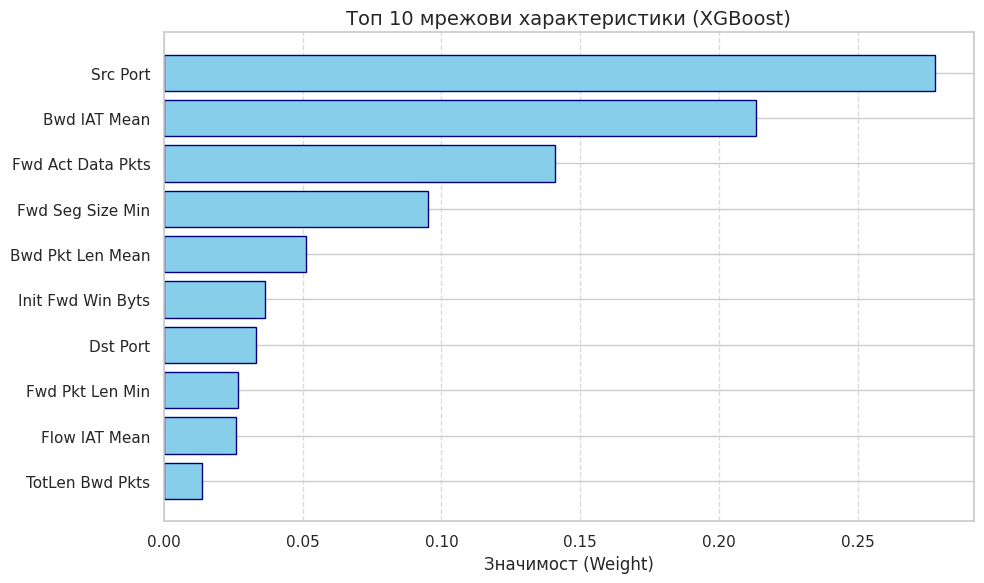

<Figure size 1000x500 with 0 Axes>

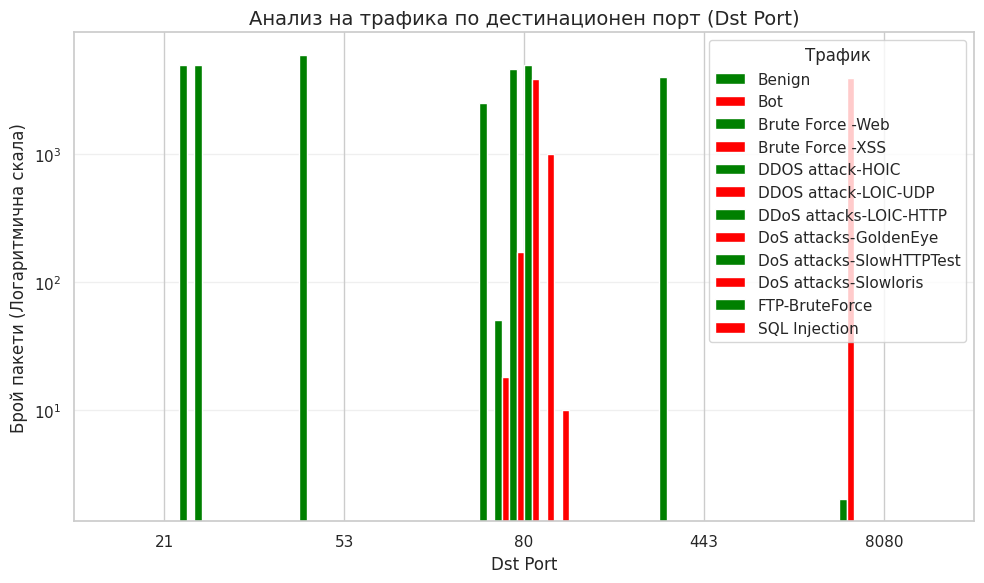

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- ГРАФИКА 1: ФОРСИРАН FEATURE IMPORTANCE ---
plt.figure(figsize=(10, 6))

# Вземаме топ 10
top_10 = feat_importances.nlargest(10)

# Рисуваме с базов Matplotlib (по-малко грешки от Seaborn в някои сесии)
plt.barh(top_10.index, top_10.values, color='skyblue', edgecolor='navy')

plt.title('Топ 10 мрежови характеристики (XGBoost)', fontsize=14)
plt.xlabel('Значимост (Weight)', fontsize=12)
plt.gca().invert_yaxis() # Най-важният най-отгоре
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feat_imp.png')
plt.show()

# --- ГРАФИКА 2: ФОРСИРАН DST PORT АНАЛИЗ ---
plt.figure(figsize=(10, 5))

# Гледаме кои са топ 5 порта в целия сет
top_ports_data = df['Dst Port'].value_counts().nlargest(5)

# Сравняваме Benign срещу Malicious за тези портове
port_stats = df[df['Dst Port'].isin(top_ports_data.index)].groupby(['Dst Port', 'Label']).size().unstack().fillna(0)

port_stats.plot(kind='bar', stacked=False, figsize=(10, 6), color=['green', 'red'])

plt.title('Анализ на трафика по дестинационен порт (Dst Port)', fontsize=14)
plt.ylabel('Брой пакети (Логаритмична скала)')
plt.yscale('log') # Задължително, защото атаките са милиони, а нормалния трафик хиляди
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Трафик')
plt.tight_layout()
plt.savefig('dst_port.png')
plt.show()

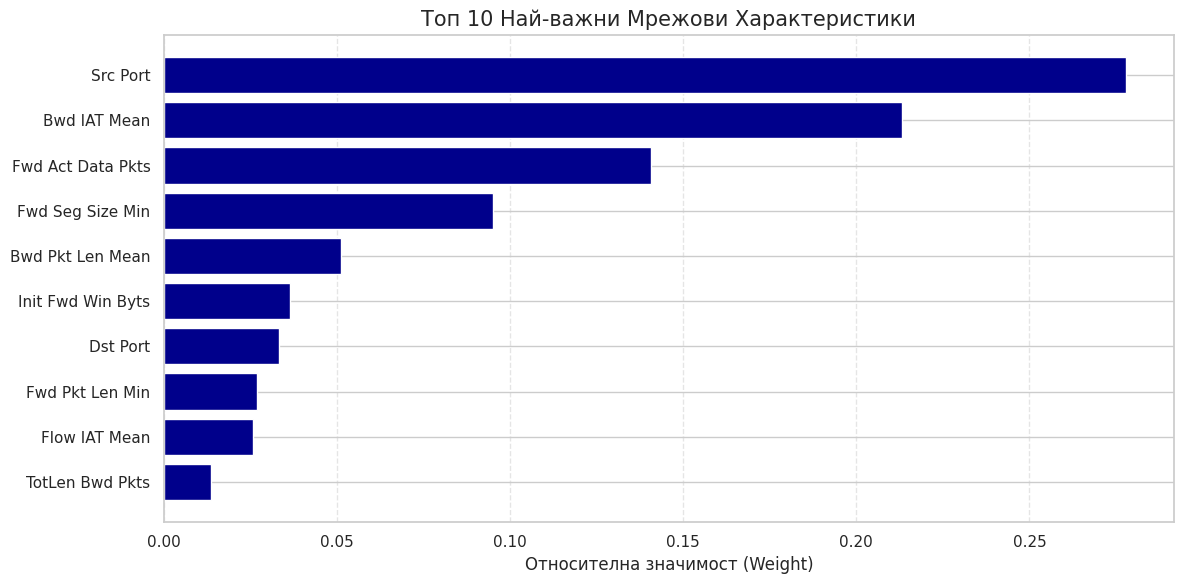

<Figure size 1200x600 with 0 Axes>

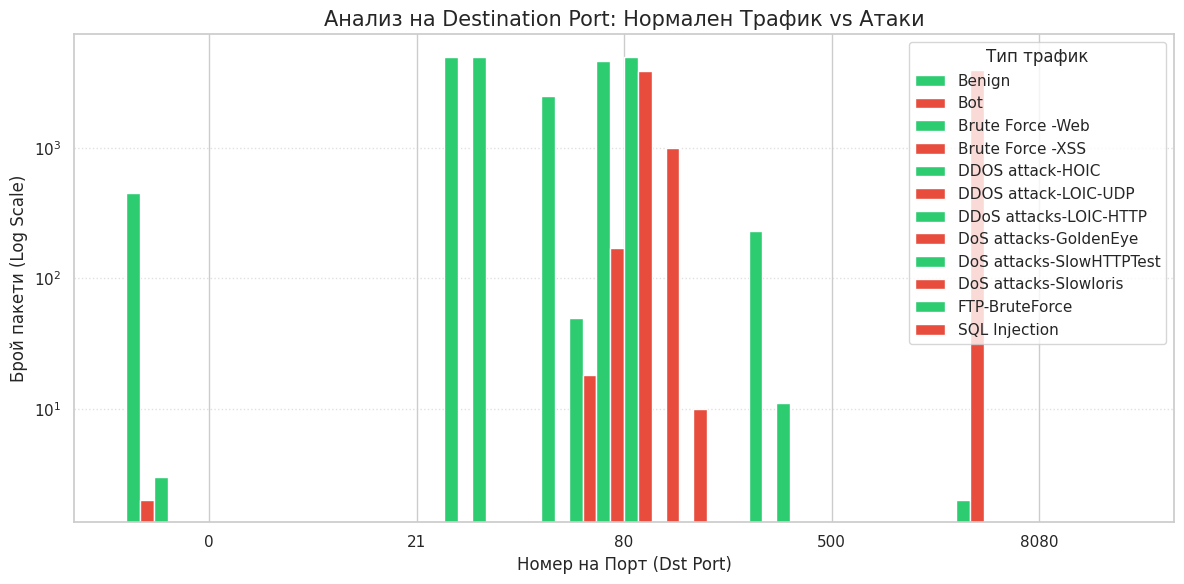

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- ГРАФИКА 1: FEATURE IMPORTANCE (ФОРСИРАНА) ---
# Вземаме теглата от вече обучения модел
importances = model_analysis.feature_importances_
indices = np.argsort(importances)[-10:] # Топ 10 индекса

plt.figure(figsize=(12, 6))
plt.title('Топ 10 Най-важни Мрежови Характеристики', fontsize=15)
plt.barh(range(len(indices)), importances[indices], color='darkblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Относителна значимост (Weight)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# --- ГРАФИКА 2: DST PORT АНОМАЛИЯ (ФОРСИРАНА) ---
plt.figure(figsize=(12, 6))

# Филтрираме топ 5 най-често срещани порта при атаките
attacks_df = df[df['Label'] != 'Benign']
top_attack_ports = attacks_df['Dst Port'].value_counts().nlargest(5).index

# Подготвяме данни за сравнение
plot_data = df[df['Dst Port'].isin(top_attack_ports)]

# Ръчно групиране за стълбовидна диаграма
pivot_df = plot_data.groupby(['Dst Port', 'Label']).size().unstack().fillna(0)

# Рисуване
pivot_df.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#e74c3c'], width=0.8)

plt.title('Анализ на Destination Port: Нормален Трафик vs Атаки', fontsize=15)
plt.ylabel('Брой пакети (Log Scale)', fontsize=12)
plt.yscale('log') # Логаритмичната скала е задължителна!
plt.xlabel('Номер на Порт (Dst Port)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Тип трафик', loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('dst_port_analysis.png')
plt.show()

In [ ]:
import os

# Проверяваме точното съдържание на папката
folder_path = '/content/drive/MyDrive/Datasets/CIC-IDS2018'

if os.path.exists(folder_path):
    files = os.listdir(folder_path)
    print(f"✅ Папката е намерена! Файлове вътре: {len(files)}")
    print(f"Първите 5 файла: {files[:5]}")
else:
    print(f"❌ Пътят Е ГРЕШЕН! Провери дали папката в Drive се казва точно 'datasets' и 'CIC-IDS2018'")

✅ Папката е намерена! Файлове вътре: 10
Първите 5 файла: ['02-14-2018.csv', '02-15-2018.csv', '02-16-2018.csv', '02-20-2018.csv', '02-21-2018.csv']


In [ ]:
import pandas as pd
import os

base_path = '/content/drive/MyDrive/Datasets/CIC-IDS2018'
# Вземаме списъка с файлове директно от папката, за да няма разминаване в имената
file_names = [f for f in os.listdir(base_path) if f.endswith('.csv')]

all_chunks = []

for name in file_names:
    full_path = os.path.join(base_path, name)
    print(f"Опит за зареждане на: {name}...", end=" ")

    try:
        # Четем само първите 50 000 реда за проба, за да не препълним RAM
        temp_df = pd.read_csv(full_path, nrows=50000, low_memory=False)

        if not temp_df.empty:
            temp_df.columns = temp_df.columns.str.strip()
            # Вземаме само 5000 реда от тези 50 000 за извадката
            sample_df = temp_df.sample(n=5000, random_state=42)
            all_chunks.append(sample_df)
            print(f"УСПЕХ! (Взети {len(sample_df)} реда)")
        else:
            print("Файлът е празен!")

    except Exception as e:
        print(f"ГРЕШКА при четене: {e}")

# Обединяваме
if all_chunks:
    df = pd.concat(all_chunks, axis=0, ignore_index=True)
    print(f"\n✅ Готoво! Общ брой редове в 'df': {len(df)}")
    print(f"Налични лейбъли: {df['Label'].unique()}")
else:
    print("\n❌ КРИТИЧНО: Нито един файл не беше зареден в 'all_chunks'!")

Опит за зареждане на: 02-14-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 02-15-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 02-16-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 02-20-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 02-21-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 02-22-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 02-23-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 02-28-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 03-01-2018.csv... УСПЕХ! (Взети 5000 реда)
Опит за зареждане на: 03-02-2018.csv... УСПЕХ! (Взети 5000 реда)

✅ Готoво! Общ брой редове в 'df': 50000
Налични лейбъли: ['FTP-BruteForce' 'Benign' 'DoS attacks-GoldenEye' 'DoS attacks-Slowloris'
 'DoS attacks-SlowHTTPTest' 'DDoS attacks-LOIC-HTTP' 'DDOS attack-HOIC'
 'DDOS attack-LOIC-UDP' 'SQL Injection' 'Brute Force -Web'
 'Brute Force -XSS' 'Bot']


In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# 1. Почистване: Премахваме текстови колони и Timestamp
X = df.drop(columns=['Label', 'Timestamp'], errors='ignore')

# Конвертираме всичко в числа (важно за Dst Port)
X = X.apply(pd.to_numeric, errors='coerce')

# Изрично заместваме inf стойностите с NaN, преди да запълним NaN с 0
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

y = df['Label']

# 2. Енкодинг на етикетите
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Кратко обучение на XGBoost специално за Feature Importance
model_analysis = xgb.XGBClassifier(n_estimators=50, max_depth=5, random_state=42)
model_analysis.fit(X, y_encoded)

print("✅ Моделът е обучен успешно върху новите данни!")

✅ Моделът е обучен успешно върху новите данни!


/tmp/ipykernel_58693/3831950283.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette="viridis")


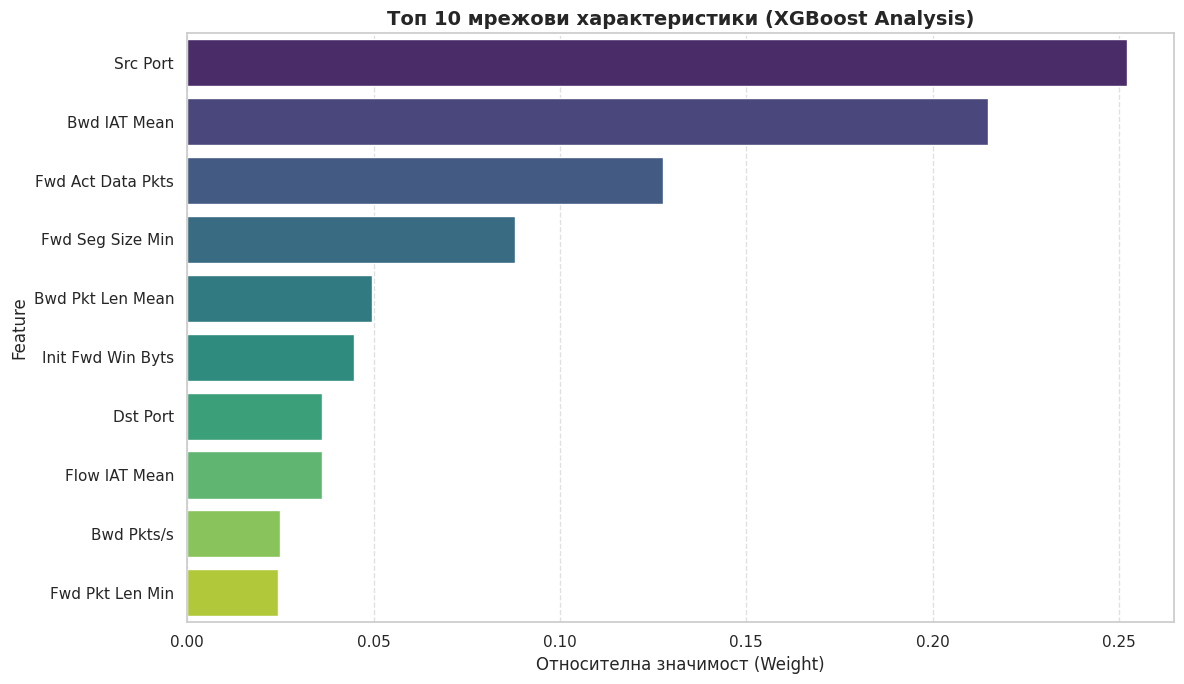

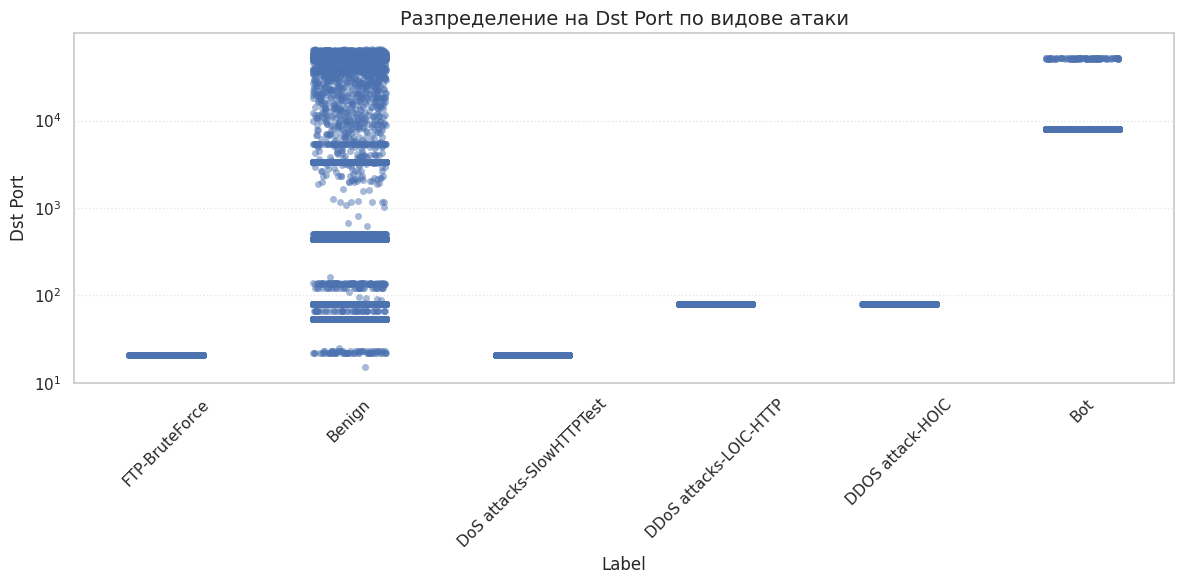

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- ГРАФИКА 1: FEATURE IMPORTANCE ---
plt.figure(figsize=(12, 7))
feat_importances = pd.Series(model_analysis.feature_importances_, index=X.columns)
top_10 = feat_importances.nlargest(10)

sns.barplot(x=top_10.values, y=top_10.index, palette="viridis")
plt.title('Топ 10 мрежови характеристики (XGBoost Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Относителна значимост (Weight)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('top_features.png')
plt.show()

# --- ГРАФИКА 2: DST PORT АНАЛИЗ ---
plt.figure(figsize=(12, 6))

# Вземаме само топ 5 атаки за по-чиста графика
top_labels = df['Label'].value_counts().nlargest(6).index
df_filtered = df[df['Label'].isin(top_labels)]

# Показваме разпределението на Dst Port за различните атаки
sns.stripplot(data=df_filtered, x='Label', y='Dst Port', jitter=0.2, alpha=0.5)
plt.title('Разпределение на Dst Port по видове атаки', fontsize=14)
plt.xticks(rotation=45)
plt.yscale('log') # Логаритмична скала за по-добра видимост на портовете
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('dst_port_distribution.png')
plt.show()

In [ ]:
# Подготовка на X и y
X = df.drop(['Label', 'Timestamp', 'Flow ID', 'Src IP', 'Dst IP'], axis=1, errors='ignore') # Премахваме ненужни колони
y = df['Label']

# Енкодинг на таргета
le = LabelEncoder()
y = le.fit_transform(y)

# Разделяне на данни
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ПРИЛАГАНЕ НА SMOTE (само върху тренировъчните данни)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Дефиниране на модели
models = {
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM (Linear)": LinearSVC(max_iter=1000)
}

results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_res, y_train_res)
    train_time = time.time() - start_time

    start_time = time.time()
    preds = model.predict(X_test)
    inference_time = time.time() - start_time

    acc = accuracy_score(y_test, preds)
    results.append({"Model": name, "Accuracy": acc, "Train Time": train_time, "Inference Time": inference_time})

# Превръщане в DataFrame за визуализация
res_df = pd.DataFrame(results)
print(res_df)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:27:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KeyboardInterrupt: 